In [13]:
print("1-Data Loading and Exploration")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder

1-Data Loading and Exploration


In [11]:
data = pd.read_csv("Housing.csv") 

In [12]:
print("First 10 rows")
print(data.head(10))

print("\nRows and Columns:", data.shape)

print("\nMissing values")
print(data.isnull().sum())
print("\ncolumns:")
print(data.columns)



First 10 rows
      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes 

In [15]:
print("2-Data Cleaning")
data = data.dropna()
data = data.drop_duplicates()

2-Data Cleaning


In [5]:
data["mainroad"] = data["mainroad"].map({"yes": 1, "no": 0})
data["guestroom"] = data["guestroom"].map({"yes": 1, "no": 0})
data["basement"] = data["basement"].map({"yes": 1, "no": 0})
data["hotwaterheating"] = data["hotwaterheating"].map({"yes": 1, "no": 0})
data["airconditioning"] = data["airconditioning"].map({"yes": 1, "no": 0})
data["prefarea"] = data["prefarea"].map({"yes": 1, "no": 0})

In [6]:
data = pd.get_dummies(
    data,
    columns=["furnishingstatus"],
    drop_first=True
)

print(data.head())

      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                            False                         False  
1                       

In [17]:
x = data[["area", "bedrooms", "bathrooms", "stories", "parking"]]
y = data["price"]

In [18]:
print("3-Model building")
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

3-Model building


In [9]:
model = LinearRegression()
model.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](5,)","[ 308.87, 151246.75,1185731.71, 495100.76, 337660.83]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](5,)","['area','bedrooms','bathrooms','stories','parking']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,5.2e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,5
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,5


In [10]:
y_pred = model.predict(x_test)

In [18]:
lr_mae  = mean_absolute_error(y_test, y_pred)
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred))
lr_r2   = r2_score(y_test, y_pred)
 
print("Linear Regression Results")
print("MAE   :", lr_mae)
print("RMSE  : ",lr_rmse)
print("R2_score    :" ,lr_r2)

Linear Regression Results
MAE   : 1127483.3523235186
RMSE  :  1514173.552049223
R2_score    : 0.5464062355495873


In [14]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(x_train, y_train)
rf_pred = rf_model.predict(x_test)

In [19]:
rf_mae  = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2   = r2_score(y_test, rf_pred)
 
print("Random Forest Results")
print("MAE   :",rf_mae)
print("RMSE  : ",rf_rmse)
print("R2    :", rf_r2)

Random Forest Results
MAE   : 1150445.3340978594
RMSE  :  1610415.5401759755
R2    : 0.48691222287234903


In [20]:
compare = pd.DataFrame({
    "Model"  : ["Linear Regression", "Random Forest"],
    "MAE"    : [lr_mae, rf_mae],
    "RMSE"   : [lr_rmse, rf_rmse],
    "R2 Score": [lr_r2, rf_r2]
})
print(compare)

               Model           MAE          RMSE  R2 Score
0  Linear Regression  1.127483e+06  1.514174e+06  0.546406
1      Random Forest  1.150445e+06  1.610416e+06  0.486912


4-Data Visualization


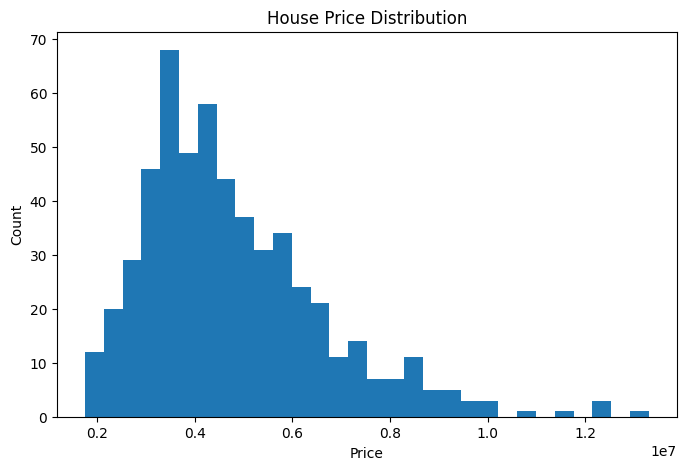

In [19]:
print("4-Data Visualization")
plt.figure(figsize=(8,5))
plt.hist(data["price"], bins=30)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

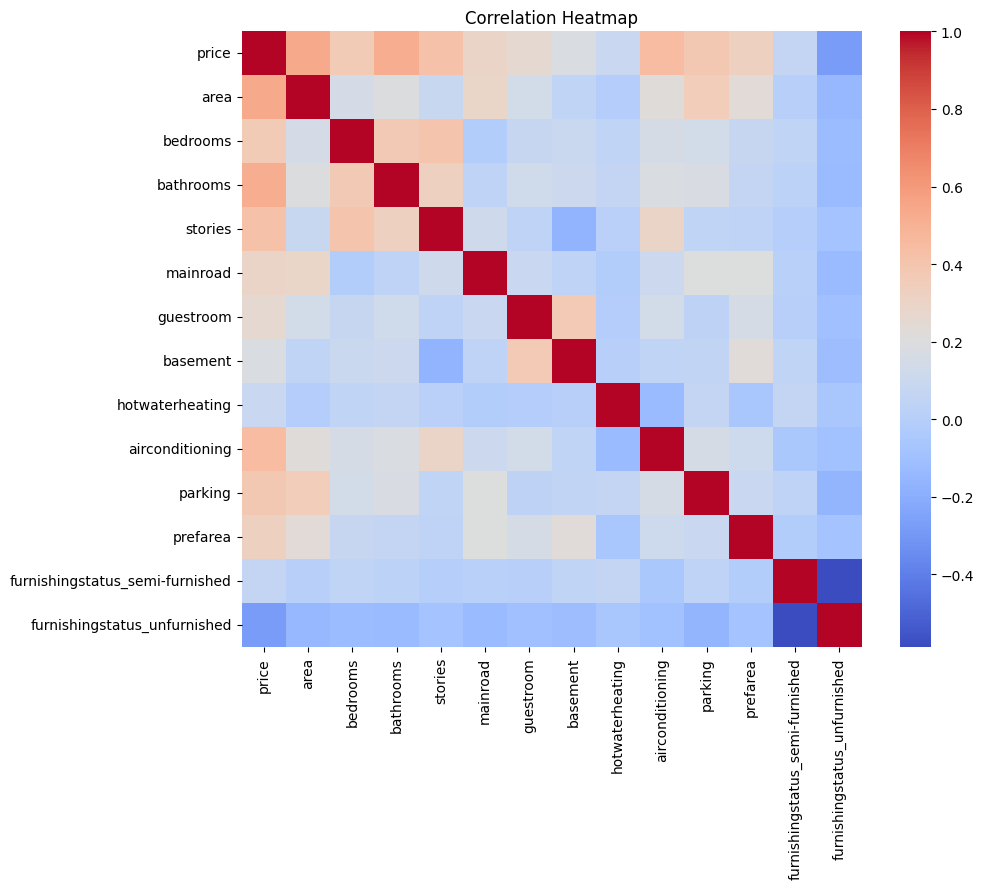

In [23]:
plt.figure(figsize=(10,8))

sns.heatmap(
    data.corr(),
    cmap="coolwarm"
)
plt.title("Correlation Heatmap")
plt.show()

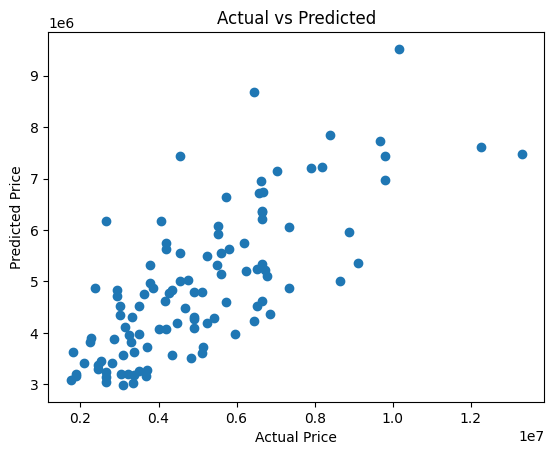

In [24]:
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.show()

In [20]:
summary=""" 5-Insights and Summary
(1)The analysis showed that area, number of bathrooms, and number of stories have the biggest effect on house prices. Features like air conditioning and houses located on the main road also increase the price.

(2)Linear Regression performed better than Random Forest. It achieved an R² score of 54%, which means it could explain about half of the changes in house prices. Random Forest scored 48%, so it was less accurate for this dataset.

(3)One surprising finding was that a simple model Linear Regression worked better than a more advanced model Random Forest. This may be because the dataset is small 545 rows and the relationship between features and price is mostly straightforward.

(4)A good recommendation for a real estate business is to focus on factors such as area, bathrooms, and stories when pricing houses. Collecting more data, such as location, house age, and nearby facilities, could further improve prediction accuracy."""
print(summary)

 5-Insights and Summary
(1)The analysis showed that area, number of bathrooms, and number of stories have the biggest effect on house prices. Features like air conditioning and houses located on the main road also increase the price.

(2)Linear Regression performed better than Random Forest. It achieved an R² score of 54%, which means it could explain about half of the changes in house prices. Random Forest scored 48%, so it was less accurate for this dataset.

(3)One surprising finding was that a simple model Linear Regression worked better than a more advanced model Random Forest. This may be because the dataset is small 545 rows and the relationship between features and price is mostly straightforward.

(4)A good recommendation for a real estate business is to focus on factors such as area, bathrooms, and stories when pricing houses. Collecting more data, such as location, house age, and nearby facilities, could further improve prediction accuracy.
